# TP0 – Taller de Programación
## APIs y Web Scraping

Alumno: Pablo Javier Ortiz Díaz

Objetivo:
Aplicar herramientas básicas de Python para la obtención, procesamiento y visualización de datos mediante APIs y técnicas de web scraping.

# Código final ordenado del TP0

## Descarga de la Serie 1
Se descarga la serie de gasto público nacional en Justicia desde la API de Series de Tiempo de Argentina.

In [1]:
# ============================================================
# TP0 - Taller de Programación
# Código final ordenado
# ============================================================

# Librerías
import requests
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

# ============================================================
# PARTE A - APIs
# ============================================================

# Serie 1: Gasto público nacional en Justicia
id_serie_1 = "451.3_GPN_JUSTICCIA_0_0_12_92"

url_api = "https://apis.datos.gob.ar/series/api/series"

params_1 = {
    "ids": id_serie_1,
    "format": "json"
}

r1 = requests.get(url_api, params=params_1)
datos_serie_1 = r1.json()

df_serie_1 = pd.DataFrame(
    datos_serie_1["data"],
    columns=["fecha", "gasto_nacional_justicia"]
)

df_serie_1.head()

,fecha,gasto_nacional_justicia
0,1980-01-01,0.0054
1,1981-01-01,0.0089
2,1982-01-01,0.0208
3,1983-01-01,0.1229
4,1984-01-01,1.0722


In [3]:
# ============================================================
# Serie 2: Gasto público consolidado en Justicia
# ============================================================

id_serie_2 = "451.1_GPC_JUSTICCIA_0_0_12_84"

params_2 = {
    "ids": id_serie_2,
    "format": "json"
}

r2 = requests.get(url_api, params=params_2)
datos_serie_2 = r2.json()

df_serie_2 = pd.DataFrame(
    datos_serie_2["data"],
    columns=["fecha", "gasto_consolidado_justicia"]
)

df_serie_2.head()

,fecha,gasto_consolidado_justicia
0,1980-01-01,0.014006
1,1981-01-01,0.024700
2,1982-01-01,0.055700
3,1983-01-01,0.325300
4,1984-01-01,2.698808


## Estadísticas descriptivas
Se obtienen medidas resumen para ambas series.

In [4]:
# Estadísticas descriptivas

print("Serie 1")
print(df_serie_1.describe())

print("\nSerie 2")
print(df_serie_2.describe())

Serie 1
       gasto_nacional_justicia
count                44.000000
mean              37667.535109
std              123939.907972
min                   0.005400
25%                 257.307177
50%                 807.791581
75%                9290.972172
max              749938.672088

Serie 2
       gasto_consolidado_justicia
count                4.400000e+01
mean                 1.175903e+05
std                  3.907700e+05
min                  1.400557e-02
25%                  8.296164e+02
50%                  2.608781e+03
75%                  2.859511e+04
max                  2.386233e+06


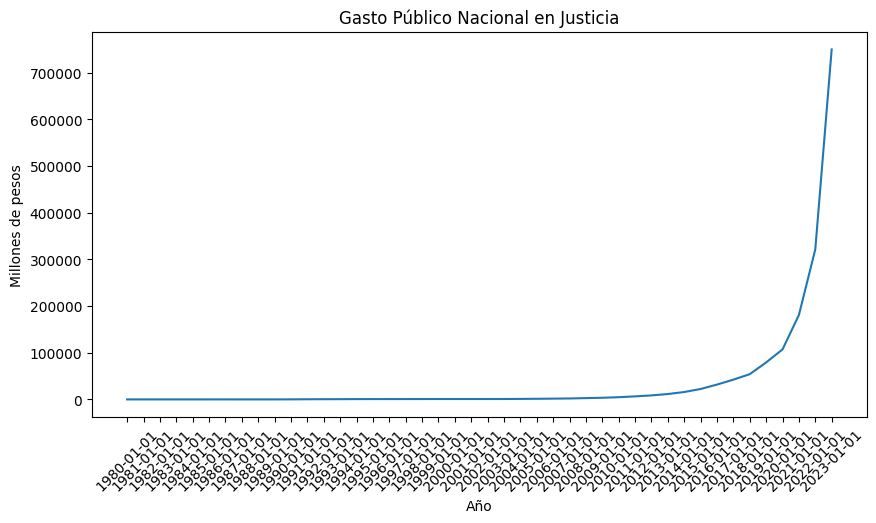

In [5]:
# Gráfico Serie 1

plt.figure(figsize=(10,5))
plt.plot(
    df_serie_1["fecha"],
    df_serie_1["gasto_nacional_justicia"]
)
plt.title("Gasto Público Nacional en Justicia")
plt.xlabel("Año")
plt.ylabel("Millones de pesos")
plt.xticks(rotation=45)
plt.show()

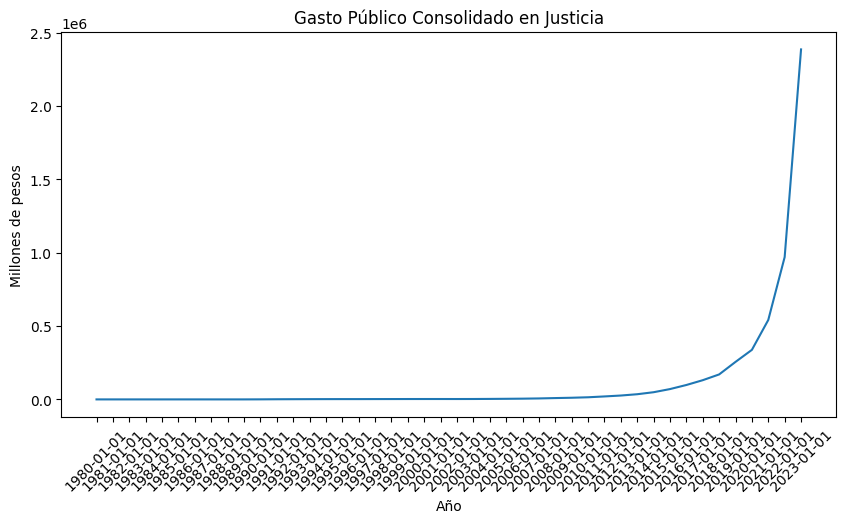

In [6]:
# Gráfico Serie 2

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    df_serie_2["fecha"],
    df_serie_2["gasto_consolidado_justicia"]
)

ax.set_title("Gasto Público Consolidado en Justicia")
ax.set_xlabel("Año")
ax.set_ylabel("Millones de pesos")

plt.xticks(rotation=45)
plt.show()

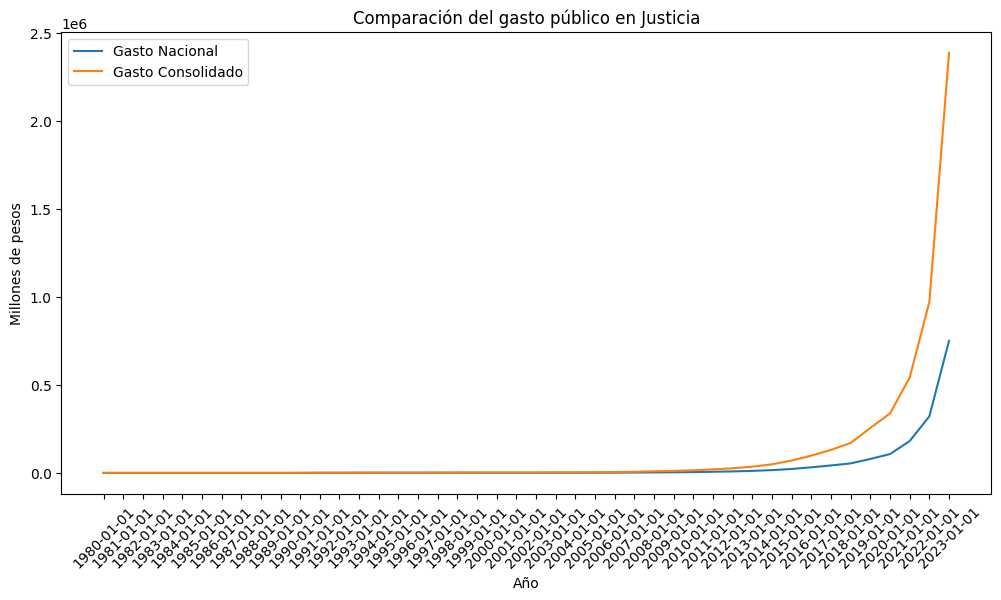

In [14]:
# Comparación de ambas series

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    df_serie_1["fecha"],
    df_serie_1["gasto_nacional_justicia"],
    label="Gasto Nacional"
)

ax.plot(
    df_serie_2["fecha"],
    df_serie_2["gasto_consolidado_justicia"],
    label="Gasto Consolidado"
)

ax.legend()
ax.set_title("Comparación del gasto público en Justicia")
ax.set_xlabel("Año")
ax.set_ylabel("Millones de pesos")

plt.xticks(rotation=45)
plt.show()

# Parte B – Web Scraping

En esta sección se extraen titulares y enlaces desde dos diarios: La Nación, como diario argentino, y BBC News, como diario extranjero.

In [8]:
# ============================================================
# PARTE B - Web Scraping
# Diario argentino: La Nación
# ============================================================

url_argentina = "https://www.lanacion.com.ar"

pagina_argentina = requests.get(url_argentina)
print(pagina_argentina.status_code)

soup_argentina = BeautifulSoup(pagina_argentina.text, "html.parser")

links_argentina = soup_argentina.find_all("a")

titulos_argentina = []
links_argentina_lista = []

for t in links_argentina:
    texto = t.get_text(strip=True)
    link = t.get("href")

    if texto != "" and link:
        titulos_argentina.append(texto)
        links_argentina_lista.append(link)

df_arg = pd.DataFrame({
    "Titular Argentina": titulos_argentina,
    "Link Argentina": links_argentina_lista
})

df_arg["Link Argentina"] = df_arg["Link Argentina"].apply(
    lambda x: "https://www.lanacion.com.ar" + x
    if x.startswith("/")
    else x
)

df_arg_limpio = df_arg[
    (df_arg["Titular Argentina"].str.len() > 25) &
    (df_arg["Link Argentina"].str.contains("lanacion.com.ar")) &
    (~df_arg["Link Argentina"].str.contains(
        "clima|dolar|juegos|suscriptores|newsletter|club|foodit|canchallena|ultimas-noticias",
        case=False
    ))
].drop_duplicates()

df_arg_limpio.head(20)

200


,Titular Argentina,Link Argentina
99,Asume el martes.Santilli llega a la Jefatura d...,https://www.lanacion.com.ar/politica/santilli-...
100,"VIDEO""Sigo confiando en su inocencia"".Milei de...",https://www.lanacion.com.ar/politica/javier-mi...
101,Críticas veladas a Macri.Bullrich dijo que una...,https://www.lanacion.com.ar/lnmas/patricia-bul...
102,Caso $LIBRA.El fideicomiso fantasma que oculta...,https://www.lanacion.com.ar/politica/caso-libr...
103,Análisis.Cambio de nombres y estilos para sost...,https://www.lanacion.com.ar/politica/cambio-de...
104,Mundial 2026.Las cifras que dejó la fase de gr...,https://www.lanacion.com.ar/deportes/futbol/la...
105,videoRetroceso en Austria.El Alpine traiciona ...,https://www.lanacion.com.ar/deportes/automovil...
106,A FondoLa razón de la Copa.A 40 años de México...,https://www.lanacion.com.ar/deportes/a-40-anos...
107,Solo en Off.Mientras entroniza a Diego Santill...,https://www.lanacion.com.ar/politica/solo-en-o...
108,A través de Cancillería.El Gobierno confirmó l...,https://www.lanacion.com.ar/sociedad/el-gobier...


In [9]:
# ============================================================
# Diario extranjero: BBC News
# ============================================================

url_extranjero = "https://www.bbc.com/news"

pagina_extranjero = requests.get(url_extranjero)
print(pagina_extranjero.status_code)

soup_extranjero = BeautifulSoup(pagina_extranjero.text, "html.parser")

links_extranjero = soup_extranjero.find_all("a")

titulos_extranjero = []
links_extranjero_lista = []

for t in links_extranjero:
    texto = t.get_text(strip=True)
    link = t.get("href")

    if texto != "" and link:
        titulos_extranjero.append(texto)
        links_extranjero_lista.append(link)

df_bbc = pd.DataFrame({
    "Titular Extranjero": titulos_extranjero,
    "Link Extranjero": links_extranjero_lista
})

df_bbc["Link Extranjero"] = df_bbc["Link Extranjero"].apply(
    lambda x: "https://www.bbc.com" + x
    if x.startswith("/")
    else x
)

df_bbc_limpio = df_bbc[
    (df_bbc["Titular Extranjero"].str.len() > 30) &
    (~df_bbc["Link Extranjero"].str.contains(
        "signin|account|register|sport|weather|iplayer",
        case=False
    ))
].drop_duplicates()

df_bbc_limpio.head(20)

200


,Titular Extranjero,Link Extranjero
2,British Broadcasting Corporation,https://www.bbc.com/
120,LIVEMore search teams arrive in Venezuela but ...,https://www.bbc.com/news/live/cz9l490v5ldt
121,Anger directed at Venezuela's official respons...,https://www.bbc.com/news/videos/cj4glezz1jvo
122,South Korea football coach quits as president ...,https://www.bbc.com/news/articles/cdx7jk0kq4vo
123,Princess of Wales climbs three UK peaks to 'ex...,https://www.bbc.com/news/articles/cwydwgy7125o
124,Pakistani strikes kill dozens in AfghanistanTh...,https://www.bbc.com/news/articles/cy8wygyed0wo
125,How population decline is exposing Germany's o...,https://www.bbc.com/news/articles/c24ylyv40y5o
127,First dinosaur bone from Antarctica found in a...,https://www.bbc.com/news/articles/cdep67jnn9zo
128,US says it has agreed with Iran to 'stand down...,https://www.bbc.com/news/articles/c872rjw17qpo
129,"Europe's heatwave linked to 1,300 deaths, WHO ...",https://www.bbc.com/news/articles/cn4d2vv935lo


In [10]:
# ============================================================
# Unión de ambos diarios
# ============================================================

df_arg_final = df_arg_limpio.reset_index(drop=True).head(20)
df_bbc_final = df_bbc_limpio.reset_index(drop=True).head(20)

df_noticias = pd.concat([df_arg_final, df_bbc_final], axis=1)

df_noticias

,Titular Argentina,Link Argentina,Titular Extranjero,Link Extranjero
0,Asume el martes.Santilli llega a la Jefatura d...,https://www.lanacion.com.ar/politica/santilli-...,British Broadcasting Corporation,https://www.bbc.com/
1,"VIDEO""Sigo confiando en su inocencia"".Milei de...",https://www.lanacion.com.ar/politica/javier-mi...,LIVEMore search teams arrive in Venezuela but ...,https://www.bbc.com/news/live/cz9l490v5ldt
2,Críticas veladas a Macri.Bullrich dijo que una...,https://www.lanacion.com.ar/lnmas/patricia-bul...,Anger directed at Venezuela's official respons...,https://www.bbc.com/news/videos/cj4glezz1jvo
3,Caso $LIBRA.El fideicomiso fantasma que oculta...,https://www.lanacion.com.ar/politica/caso-libr...,South Korea football coach quits as president ...,https://www.bbc.com/news/articles/cdx7jk0kq4vo
4,Análisis.Cambio de nombres y estilos para sost...,https://www.lanacion.com.ar/politica/cambio-de...,Princess of Wales climbs three UK peaks to 'ex...,https://www.bbc.com/news/articles/cwydwgy7125o
5,Mundial 2026.Las cifras que dejó la fase de gr...,https://www.lanacion.com.ar/deportes/futbol/la...,Pakistani strikes kill dozens in AfghanistanTh...,https://www.bbc.com/news/articles/cy8wygyed0wo
6,videoRetroceso en Austria.El Alpine traiciona ...,https://www.lanacion.com.ar/deportes/automovil...,How population decline is exposing Germany's o...,https://www.bbc.com/news/articles/c24ylyv40y5o
7,A FondoLa razón de la Copa.A 40 años de México...,https://www.lanacion.com.ar/deportes/a-40-anos...,First dinosaur bone from Antarctica found in a...,https://www.bbc.com/news/articles/cdep67jnn9zo
8,Solo en Off.Mientras entroniza a Diego Santill...,https://www.lanacion.com.ar/politica/solo-en-o...,US says it has agreed with Iran to 'stand down...,https://www.bbc.com/news/articles/c872rjw17qpo
9,A través de Cancillería.El Gobierno confirmó l...,https://www.lanacion.com.ar/sociedad/el-gobier...,"Europe's heatwave linked to 1,300 deaths, WHO ...",https://www.bbc.com/news/articles/cn4d2vv935lo


In [11]:
# Exportar archivo CSV

df_noticias.to_csv(
    "links_noticias_TP0.csv",
    index=False,
    encoding="utf-8-sig"
)

In [12]:
from google.colab import files

files.download("links_noticias_TP0.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusiones finales

En el presente trabajo se utilizaron herramientas básicas de Python para acceder, procesar y visualizar datos provenientes de internet.

En la Parte A se trabajó con la API de Series de Tiempo de Argentina, descargando dos indicadores relacionados con el gasto público en Justicia. Luego, se construyeron DataFrames, se calcularon estadísticas descriptivas y se realizaron gráficos de tendencia utilizando Matplotlib.

En la Parte B se aplicaron técnicas de web scraping sobre dos medios de comunicación: La Nación, como diario argentino, y BBC News, como diario extranjero. A partir del código desarrollado, se extrajeron titulares y enlaces de noticias, los cuales fueron organizados en un DataFrame y exportados a un archivo CSV.

El trabajo permitió familiarizarse con librerías relevantes para el análisis de datos, como requests, pandas, matplotlib y BeautifulSoup. Asimismo, permitió comprender el flujo básico de trabajo en programación aplicada: obtener datos, limpiarlos, analizarlos, visualizarlos y exportarlos.